In [1]:
import pandas as pd
import warnings
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

##### Import Datasets

In [2]:
dfpop = pd.read_csv('Raw Data/historical_state_population_by_year.csv')
dfgdp = pd.read_excel('Raw Data/Table.xlsx', skiprows=5, nrows=416)
dfres = pd.read_excel('Raw Data/ncses_table_formatted_data_SGRD_2026-02-27T20_42_43Z.xlsx')
df500 = pd.read_excel('Raw Data/f500_growth.xlsx')

# Clean Data

##### Get the state conversion dictionary

In [3]:
us_states = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'DC': 'District of Columbia', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}
df500['state'] = df500['state'].map(us_states)

### Fill F500 gaps — states with zero Fortune 500 companies and missing years

In [4]:
# Build a complete state x year grid and fill missing entries with 0
all_years = range(df500['year'].min(), df500['year'].max() + 1)
all_states_full = list(us_states.values())
full_grid = pd.MultiIndex.from_product([all_states_full, all_years], names=['state', 'year'])
df500 = df500.set_index(['state', 'year']).reindex(full_grid).reset_index()
df500['f500_count'] = df500['f500_count'].fillna(0).astype(int)
# Recalculate pct_change per state
df500 = df500.sort_values(['state', 'year'])
df500['f500_pct_change'] = df500.groupby('state')['f500_count'].pct_change()
df500.loc[df500['f500_pct_change'].isin([float('inf'), float('-inf')]), 'f500_pct_change'] = float('nan')

### Clean Research Dataset

In [5]:
def cleanres(df):
    df.rename(columns={'State': 'state'}, inplace=True)
    df = df.drop(columns=['Fiscal Year'])
    # Remove Total and Puerto Rico rows (not in other datasets)
    df = df[~df['state'].isin(['Total', 'Puerto Rico'])].reset_index(drop=True)
    df_long = df.melt(id_vars=['state'], var_name='year', value_name='research_spending')
    df_long['research_spending'] = pd.to_numeric(df_long['research_spending'], errors='coerce')
    df_long['year'] = df_long['year'].astype(int)
    # Interpolate missing 2008 data from 2007 and 2009
    states_list = df_long['state'].unique()
    rows_2008 = []
    for state in states_list:
        s = df_long[df_long['state'] == state].sort_values('year')
        val_2007 = s.loc[s['year'] == 2007, 'research_spending']
        val_2009 = s.loc[s['year'] == 2009, 'research_spending']
        if len(val_2007) > 0 and len(val_2009) > 0:
            interp = (val_2007.values[0] + val_2009.values[0]) / 2
        else:
            interp = float('nan')
        rows_2008.append({'state': state, 'year': 2008, 'research_spending': interp})
    df_long = pd.concat([df_long, pd.DataFrame(rows_2008)], ignore_index=True)
    df_long = df_long.sort_values(['state', 'year']).reset_index(drop=True)
    return df_long

clean_res = cleanres(dfres)

### Clean Population Dataset

In [6]:
def cleanPop(df):
    df.columns = ['state_abbr', 'year', 'population']
    df['state'] = df['state_abbr'].map(us_states)
    df = df.drop(columns='state_abbr')
    #df = df.pivot(index='state', columns='year', values='population')
    return df

clean_pop = cleanPop(dfpop)
clean_pop = clean_pop[clean_pop['year'].between(1997, 2024)].reset_index(drop=True)

### Clean GDP Dataset

In [7]:
def cleangdp(df):
    df = df[df['Description'] == 'Real GDP (millions of chained 2017 dollars) 1'].reset_index(drop=True)
    df = df.drop(columns=['GeoFIPS', 'LineCode', 'Description'])
    df = df.melt(id_vars='GeoName', var_name='year', value_name='gdp')
    df['year'] = df['year'].astype(int)
    df.rename(columns={'GeoName': 'state'}, inplace=True)
    return df

clean_gdp = cleangdp(dfgdp)

### Merge Datasets Together

In [8]:
merged = pd.merge(clean_gdp, clean_pop, on=['state', 'year'], how='inner')
merged['gdp_1000000'] = merged['gdp']
merged['gdp'] = merged['gdp'] * 1000000
merged['gdp_per_capita'] = merged['gdp'] / merged['population']


merged2 = pd.merge(merged, clean_res, on=['state', 'year'], how='inner')
merged3 = pd.merge(merged2, df500, on=['state', 'year'], how='inner')

##### Describe Data

In [9]:
merged3.describe().loc[['mean', '50%', 'std']]

,year,gdp,population,gdp_1000000,gdp_per_capita,research_spending,f500_count,f500_pct_change
mean,2014.500000,3.671371e+11,6.250886e+06,367137.063072,58911.557998,40914.729364,9.797386,0.013257
50%,2014.500000,2.151522e+11,4.381723e+06,215152.150000,54913.157572,16082.187500,4.000000,0.000000
std,5.190956,4.616576e+11,7.035867e+06,461657.580258,22431.134408,84836.432983,13.560009,0.265454


##### Make Correlation CSV

In [10]:
df = merged3.drop(columns=['state']).corr()
df.to_csv('Clean Data/correlation.csv')

##### Export Merged Dataset for Visualizations

In [11]:
merged3.to_csv('Clean Data/merged_data.csv', index=False)
print(f"Exported merged_data.csv: {merged3.shape[0]} rows, {merged3.shape[1]} columns")

Exported merged_data.csv: 918 rows, 9 columns


##### Make Linear Regression

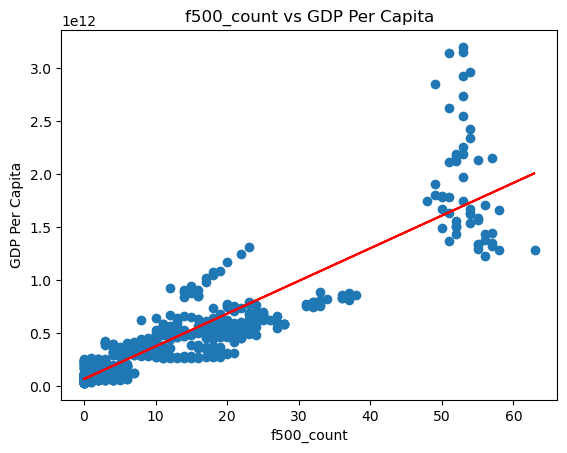

In [12]:
X = merged3['f500_count'].values.reshape(-1, 1)
y = merged3['gdp'].values.reshape(-1, 1)
LinearModel = LinearRegression()
LinearModel.fit(X, y)

plt.scatter(X, y)
plt.plot(X, LinearModel.predict(X), color='red')
plt.xlabel('f500_count')
plt.ylabel('GDP Per Capita')
plt.title('f500_count vs GDP Per Capita')
plt.show()

##### K-Means Clustering
Cluster states by GDP per capita, R&D spending per capita, and F500 companies per million people using the most recent year. Uses the elbow method to select k.

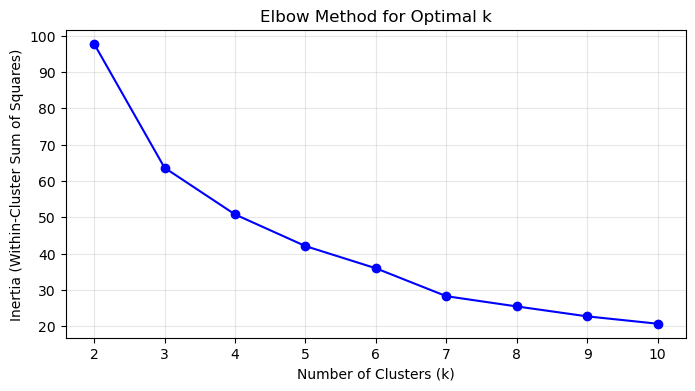

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use most recent year, exclude DC (outlier)
latest = merged3['year'].max()
snap = merged3[merged3['year'] == latest].copy()
snap = snap[snap['state'] != 'District of Columbia'].reset_index(drop=True)

# Create per-capita features for clustering
snap['rd_per_capita'] = snap['research_spending'] / snap['population'] * 1_000_000
snap['f500_per_million'] = snap['f500_count'] / (snap['population'] / 1_000_000)

features = ['gdp_per_capita', 'rd_per_capita', 'f500_per_million']
X_cluster = snap[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow plot to find optimal k
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Apply K-Means with k=4 (typical elbow for state economic data)
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
snap['cluster'] = km.fit_predict(X_scaled)

# Show cluster summary
print(f"K-Means Clustering (k={k}) — {latest} data, 50 states\n")
for c in sorted(snap['cluster'].unique()):
    cluster_states = snap[snap['cluster'] == c]
    print(f"Cluster {c} ({len(cluster_states)} states):")
    print(f"  States: {', '.join(sorted(cluster_states['state'].tolist()))}")
    print(f"  Avg GDP/capita: ${cluster_states['gdp_per_capita'].mean():,.0f}")
    print(f"  Avg R&D/capita: ${cluster_states['rd_per_capita'].mean():,.0f}")
    print(f"  Avg F500/million: {cluster_states['f500_per_million'].mean():.1f}")
    print()

K-Means Clustering (k=4) — 2023 data, 50 states

Cluster 0 (18 states):
  States: Alabama, Hawaii, Iowa, Kansas, Kentucky, Louisiana, Maryland, Mississippi, Montana, Nevada, New Hampshire, New Mexico, Oregon, South Carolina, South Dakota, Utah, Vermont, West Virginia
  Avg GDP/capita: $56,660
  Avg R&D/capita: $5,587
  Avg F500/million: 0.2

Cluster 1 (13 states):
  States: California, Colorado, Connecticut, Delaware, Illinois, Massachusetts, Minnesota, Nebraska, New Jersey, New York, Texas, Virginia, Washington
  Avg GDP/capita: $76,701
  Avg R&D/capita: $9,887
  Avg F500/million: 2.1

Cluster 2 (15 states):
  States: Arizona, Arkansas, Florida, Georgia, Idaho, Indiana, Michigan, Missouri, North Carolina, Ohio, Oklahoma, Pennsylvania, Rhode Island, Tennessee, Wisconsin
  Avg GDP/capita: $56,321
  Avg R&D/capita: $5,266
  Avg F500/million: 1.6

Cluster 3 (4 states):
  States: Alaska, Maine, North Dakota, Wyoming
  Avg GDP/capita: $68,585
  Avg R&D/capita: $27,504
  Avg F500/million: 0.

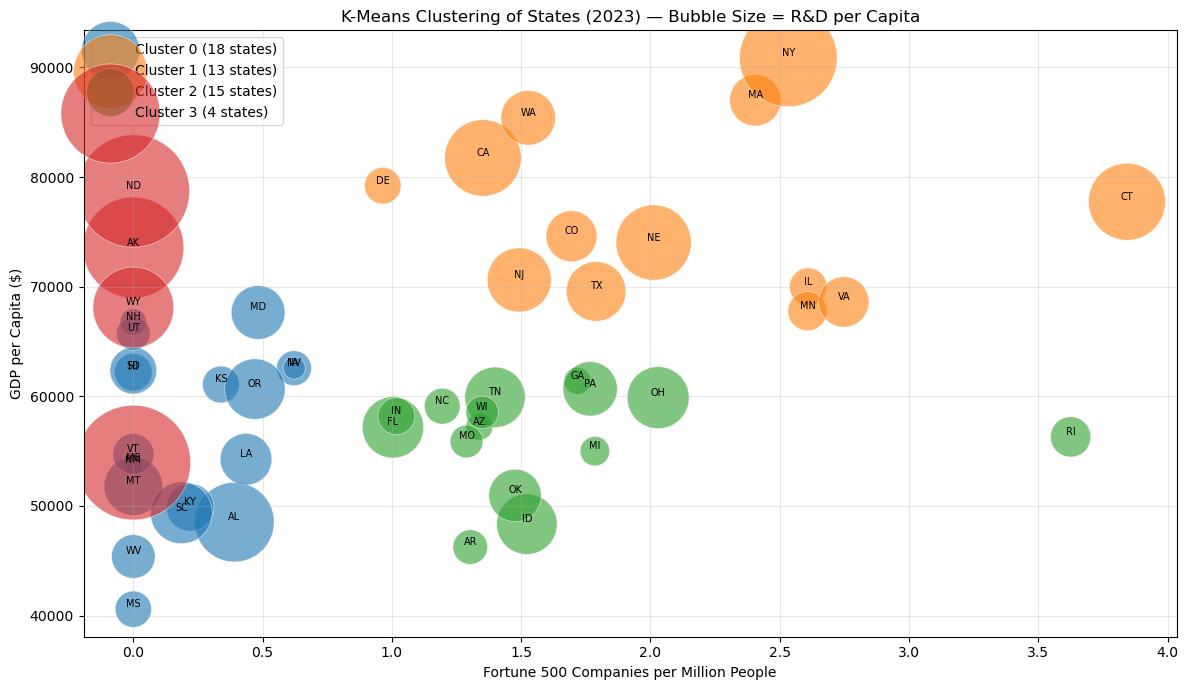

In [15]:
# Visualize clusters: GDP per capita vs F500 per million, sized by R&D per capita
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
abbr_map = {v: k for k, v in us_states.items()}

fig, ax = plt.subplots(figsize=(12, 7))
for c in sorted(snap['cluster'].unique()):
    cluster_data = snap[snap['cluster'] == c]
    ax.scatter(cluster_data['f500_per_million'], cluster_data['gdp_per_capita'],
               s=cluster_data['rd_per_capita'] / 5,
               c=colors[c], alpha=0.6, edgecolors='white', linewidth=0.5,
               label=f'Cluster {c} ({len(cluster_data)} states)')
    for _, row in cluster_data.iterrows():
        ax.annotate(abbr_map[row['state']], (row['f500_per_million'], row['gdp_per_capita']),
                    fontsize=7, ha='center', va='bottom')

ax.set_xlabel('Fortune 500 Companies per Million People')
ax.set_ylabel('GDP per Capita ($)')
ax.set_title(f'K-Means Clustering of States ({latest}) — Bubble Size = R&D per Capita')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()